# Stage 4: Evaluation Metrics

Demonstrates tracking evaluation using standard MOT metrics:
1. MOTA (Multiple Object Tracking Accuracy)
2. MOTP (Multiple Object Tracking Precision)
3. Track duration statistics
4. Fragmentation analysis
5. Detection precision/recall


In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import glob
import sys
sys.path.append('..')

from detector import ObjectDetector
from tracker import ObjectTracker
from evaluation import TrackingMetrics

plt.rcParams['figure.figsize'] = (15, 10)


## Setup Pipeline


In [2]:
frame_files = sorted(glob.glob("../data/images/bees_short/images/*.jpg"))
frames = [cv2.imread(f) for f in frame_files]

detector = ObjectDetector(history=500, dist_threshold=800, min_area=30, max_area=100000)
tracker = ObjectTracker(max_distance=30.0, min_hits=3, max_age=30)
metrics = TrackingMetrics()

print(f"Loaded {len(frames)} frames")
print(f"Frame shape: {frames[0].shape}")


Loaded 840 frames
Frame shape: (1156, 2052, 3)


## Process Video and Collect Metrics


In [3]:
all_tracks_history = []

for i, frame in enumerate(frames):
    detections = detector.detect(frame)
    tracks = tracker.update(detections)
    confirmed_tracks = tracker.get_confirmed_tracks()
    
    metrics.update(i, detections, confirmed_tracks)
    all_tracks_history.append(confirmed_tracks)
    
    if i % 50 == 0:
        print(f"Processed frame {i}/{len(frames)}")

print(f"\nProcessing complete!")
print(f"Total frames: {len(frames)}")
print(f"Unique tracks: {len(metrics.track_durations)}")


Processed frame 0/840
Processed frame 50/840
Processed frame 100/840
Processed frame 150/840
Processed frame 200/840
Processed frame 250/840
Processed frame 300/840
Processed frame 350/840
Processed frame 400/840
Processed frame 450/840
Processed frame 500/840
Processed frame 550/840
Processed frame 600/840
Processed frame 650/840
Processed frame 700/840
Processed frame 750/840
Processed frame 800/840

Processing complete!
Total frames: 840
Unique tracks: 4853


## Compute and Display Metrics

**Note:** MOTA, MOTP, Precision, and Recall require ground truth annotations (manual labels).
Without ground truth, we can still compute useful tracking statistics!


In [ ]:
# Print full summary (includes zero metrics for ground-truth-dependent values)
metrics.print_summary()

all_metrics = metrics.compute_all_metrics()

print("\n" + "="*60)
print("USEFUL METRICS WITHOUT GROUND TRUTH")
print("="*60)
print(f"\nTrack Statistics:")
print(f"  Total Tracks:        {all_metrics['total_tracks']}")
print(f"  Avg Track Duration:  {all_metrics['mean']:.2f} frames")
print(f"  Min Duration:        {all_metrics['min']} frames")
print(f"  Max Duration:        {all_metrics['max']} frames")
print(f"  Median Duration:     {all_metrics['median']:.2f} frames")
print(f"  Std Deviation:       {all_metrics['std']:.2f} frames")

print(f"\nFragmentation Analysis:")
print(f"  Total Fragments:     {all_metrics['fragments']}")
print(f"  Fragmentation Rate:  {all_metrics['fragmentation_rate']:.3f}")
print(f"  (Tracks < 10 frames)")

print(f"\nProcessing:")
print(f"  Total Frames:        {all_metrics['total_frames']}")
print(f"  Avg Tracks/Frame:    {np.mean([len(t) for t in all_tracks_history]):.2f}")

print("\n" + "="*60)


TRACKING EVALUATION METRICS

MOT Metrics:
  MOTA (Accuracy):     0.000
  MOTP (Precision):    0.000 pixels
  ID Switches:         0

Detection Quality:
  Precision:           0.000
  Recall:              0.000
  F1 Score:            0.000
  True Positives:      0
  False Positives:     0
  False Negatives:     0

Track Statistics:
  Total Tracks:        4853
  Fragments:           55
  Fragmentation Rate:  0.011
  Avg Duration:        57.38 frames
  Min Duration:        1 frames
  Max Duration:        689 frames
  Median Duration:     42.00 frames

Processing:
  Total Frames:        840

USEFUL METRICS WITHOUT GROUND TRUTH

Track Statistics:
  Total Tracks:        4853
  Avg Track Duration:  57.38 frames
  Min Duration:        1 frames
  Max Duration:        689 frames
  Median Duration:     42.00 frames
  Std Deviation:       41.98 frames

Fragmentation Analysis:
  Total Fragments:     55
  Fragmentation Rate:  0.011
  (Tracks < 10 frames)

Processing:
  Total Frames:        840
  Avg

## Track Duration Visualization


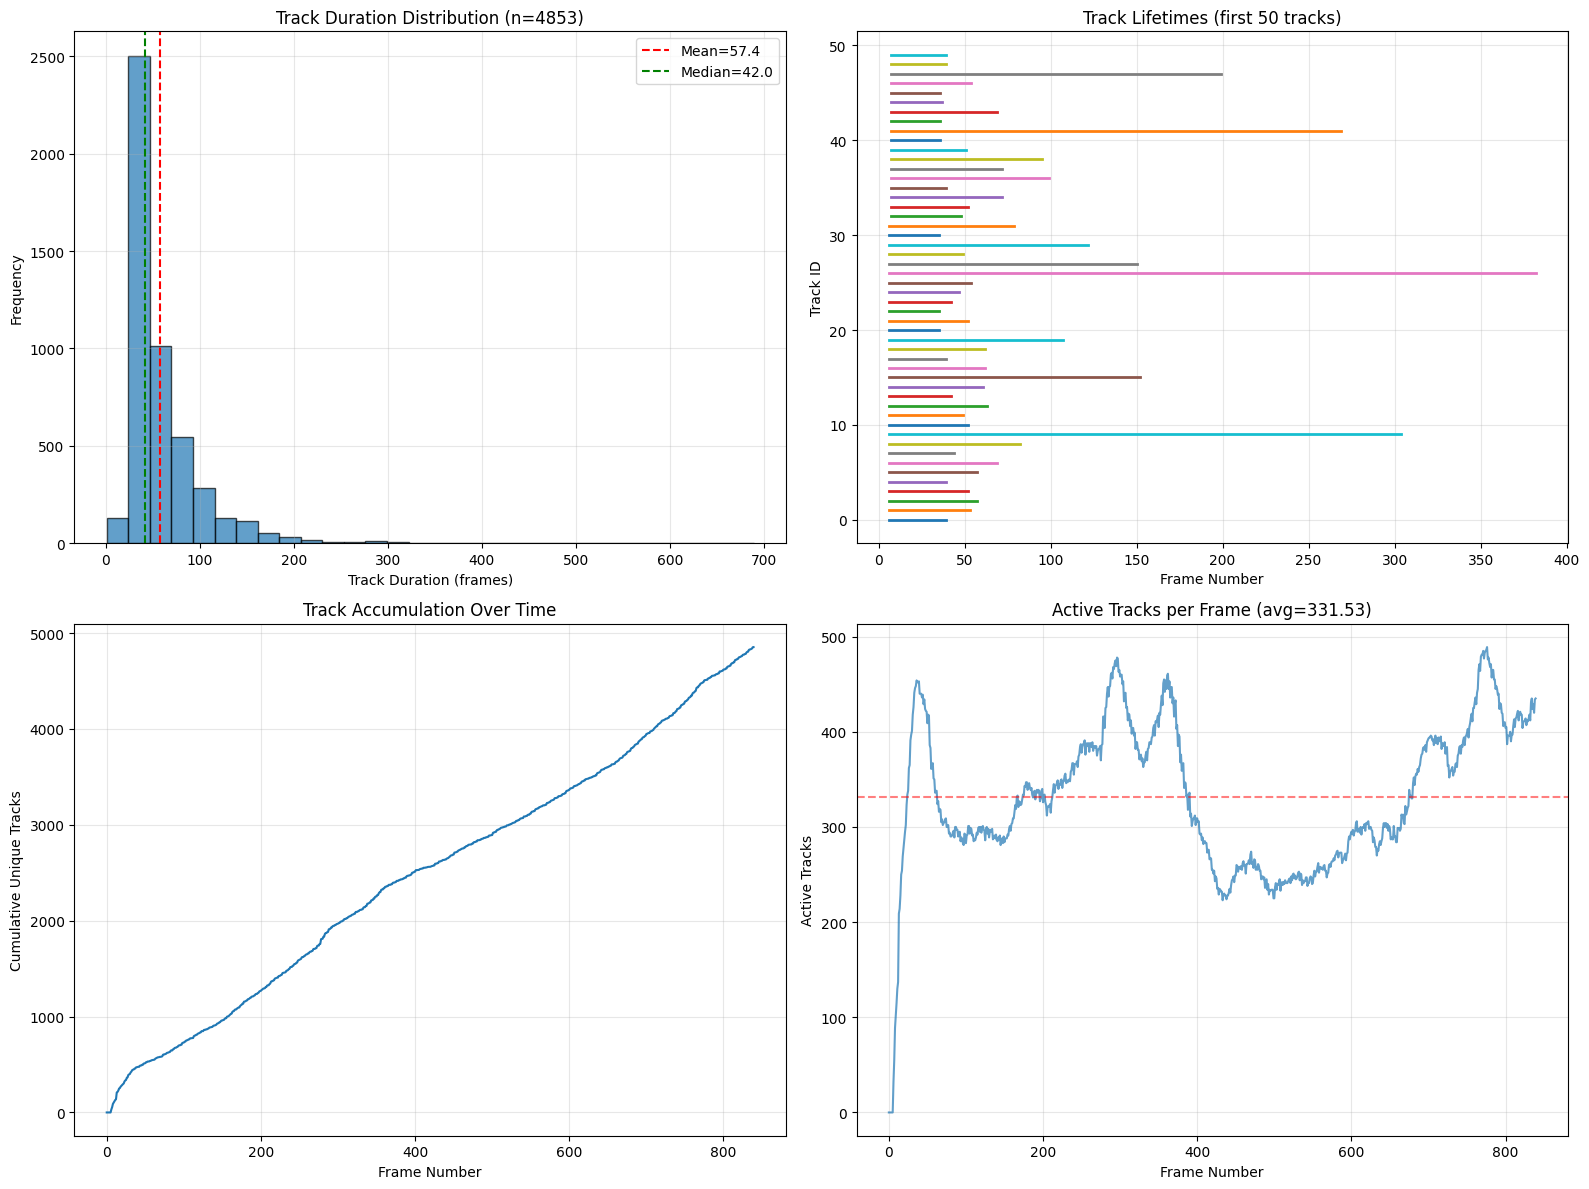

In [ ]:
durations = list(metrics.track_durations.values())

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Histogram
axes[0, 0].hist(durations, bins=30, edgecolor='black', alpha=0.7)
axes[0, 0].set_xlabel('Track Duration (frames)')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].set_title(f'Track Duration Distribution (n={len(durations)})')
axes[0, 0].axvline(np.mean(durations), color='red', linestyle='--', label=f'Mean={np.mean(durations):.1f}')
axes[0, 0].axvline(np.median(durations), color='green', linestyle='--', label=f'Median={np.median(durations):.1f}')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Timeline
track_ids = list(metrics.track_durations.keys())
for i, tid in enumerate(track_ids[:50]):
    start = metrics.track_first_seen[tid]
    end = metrics.track_last_seen[tid]
    axes[0, 1].plot([start, end], [i, i], linewidth=2)

axes[0, 1].set_xlabel('Frame Number')
axes[0, 1].set_ylabel('Track ID')
axes[0, 1].set_title('Track Lifetimes (first 50 tracks)')
axes[0, 1].grid(True, alpha=0.3)

# Cumulative tracks
cumulative_tracks = []
active_tracks = set()
for i, tracks in enumerate(all_tracks_history):
    for track in tracks:
        active_tracks.add(track.id)
    cumulative_tracks.append(len(active_tracks))

axes[1, 0].plot(cumulative_tracks)
axes[1, 0].set_xlabel('Frame Number')
axes[1, 0].set_ylabel('Cumulative Unique Tracks')
axes[1, 0].set_title('Track Accumulation Over Time')
axes[1, 0].grid(True, alpha=0.3)

# Active tracks per frame
active_per_frame = [len(tracks) for tracks in all_tracks_history]
axes[1, 1].plot(active_per_frame, alpha=0.7)
axes[1, 1].set_xlabel('Frame Number')
axes[1, 1].set_ylabel('Active Tracks')
axes[1, 1].set_title(f'Active Tracks per Frame (avg={np.mean(active_per_frame):.2f})')
axes[1, 1].axhline(np.mean(active_per_frame), color='red', linestyle='--', alpha=0.5)
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## Comparison: Different Configurations


Strict: 576 tracks, avg duration=27.3, fragments=33
Standard: 734 tracks, avg duration=42.2, fragments=41
Loose: 538 tracks, avg duration=64.6, fragments=19


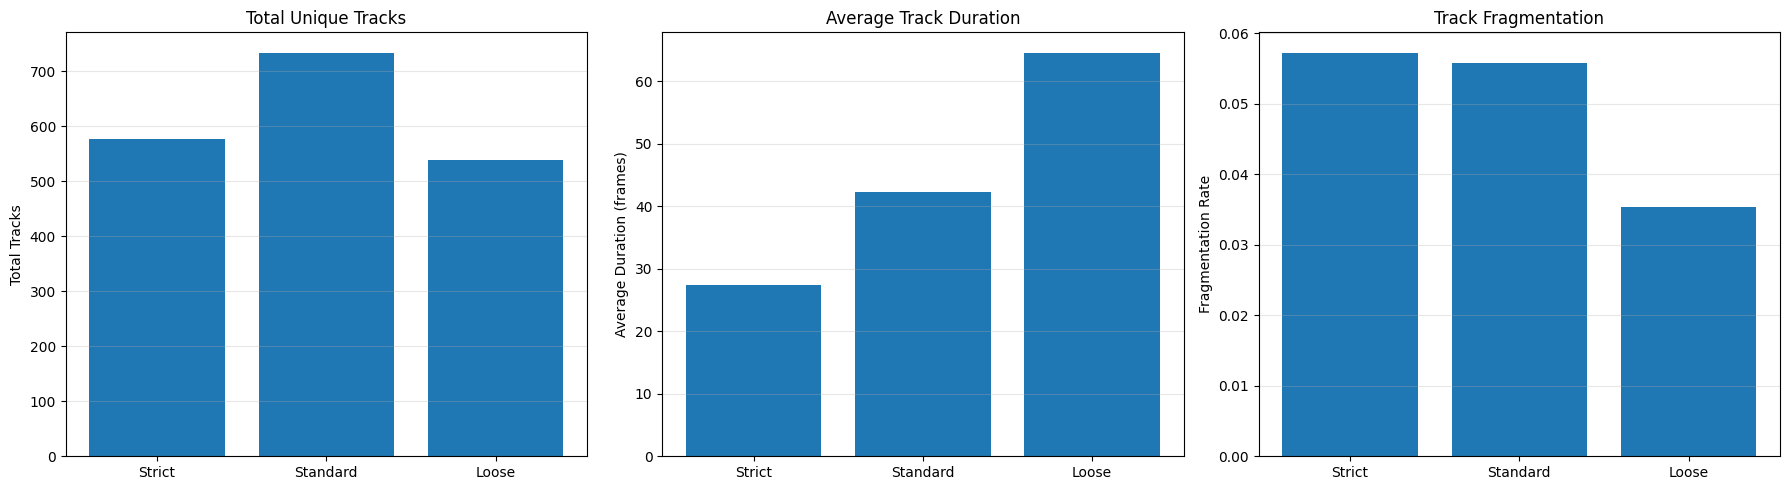

In [6]:
configs = [
    {'name': 'Strict', 'max_distance': 20.0, 'min_hits': 5, 'max_age': 15},
    {'name': 'Standard', 'max_distance': 30.0, 'min_hits': 3, 'max_age': 30},
    {'name': 'Loose', 'max_distance': 50.0, 'min_hits': 2, 'max_age': 50},
]

comparison_results = []

for config in configs:
    detector_test = ObjectDetector(history=500, dist_threshold=800, min_area=30, max_area=100000)
    tracker_test = ObjectTracker(
        max_distance=config['max_distance'],
        min_hits=config['min_hits'],
        max_age=config['max_age']
    )
    metrics_test = TrackingMetrics()
    
    for i, frame in enumerate(frames[:100]):  # Test on first 100 frames
        detections = detector_test.detect(frame)
        tracks = tracker_test.update(detections)
        confirmed = tracker_test.get_confirmed_tracks()
        metrics_test.update(i, detections, confirmed)
    
    result = metrics_test.compute_all_metrics()
    result['config'] = config['name']
    comparison_results.append(result)
    
    print(f"{config['name']}: {result['total_tracks']} tracks, avg duration={result['mean']:.1f}, fragments={result['fragments']}")

# Visualize comparison
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

configs_names = [r['config'] for r in comparison_results]

axes[0].bar(configs_names, [r['total_tracks'] for r in comparison_results])
axes[0].set_ylabel('Total Tracks')
axes[0].set_title('Total Unique Tracks')
axes[0].grid(True, alpha=0.3, axis='y')

axes[1].bar(configs_names, [r['mean'] for r in comparison_results])
axes[1].set_ylabel('Average Duration (frames)')
axes[1].set_title('Average Track Duration')
axes[1].grid(True, alpha=0.3, axis='y')

axes[2].bar(configs_names, [r['fragmentation_rate'] for r in comparison_results])
axes[2].set_ylabel('Fragmentation Rate')
axes[2].set_title('Track Fragmentation')
axes[2].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()
